In [3]:
from PIL import Image
import numpy as np
from pathlib import Path

In [8]:
import pandas as pd

# Step up one folder level to find data/milk10k/metadata.csv
METADATA_PATH = "../data/milk10k/metadata.csv"

# Load the dataset
df = pd.read_csv(METADATA_PATH)

print("Total rows:", len(df))
print("Unique lesion_id count:", df["lesion_id"].nunique())

Total rows: 10480
Unique lesion_id count: 5240


In [13]:
import pandas as pd

# Path to metadata.csv
GT_PATH = "../data/milk10k/metadata.csv"

# Load the ground truth / metadata file
gt = pd.read_csv(GT_PATH)

# Output summary
print("Total rows:", len(gt))
print("Columns:", list(gt.columns))

# Check unique lesion_id count if column exists
if "lesion_id" in gt.columns:
    print("Unique lesion_id count:", gt["lesion_id"].nunique())

Total rows: 10480
Columns: ['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_confirm_type', 'image_manipulation', 'image_type', 'lesion_id', 'melanocytic', 'sex']
Unique lesion_id count: 5240


In [14]:
print(len(gt))
gt.columns

10480


Index(['isic_id', 'attribution', 'copyright_license', 'age_approx',
       'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy',
       'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4',
       'diagnosis_confirm_type', 'image_manipulation', 'image_type',
       'lesion_id', 'melanocytic', 'sex'],
      dtype='str')

In [15]:
print("image per lesion: ")
print(df.groupby("lesion_id").size().value_counts())

image per lesion: 
2    5240
Name: count, dtype: int64


In [17]:
df.image_type.value_counts()

image_type
dermoscopic           5240
clinical: close-up    5240
Name: count, dtype: int64

Data Leakage - Train - Validation -Test Splits

In [19]:
pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/23/31/dc50d8780ac647bed9417f10a8b15ae3cf990ad7edb4f4b468f35030f8c5/scikit_learn-1.9.1-cp311-cp311-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/18/53/84099323c2ec4be98d935f63c033ac4151ee83836ca1050ede3b3aadf155/joblib-1.6.0-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.5.0 from https://files.pythonhosted.org/packages/43/3f/f88a53f60a472b46f4023f56d204dd7de33d34c5d2acbfa0d70a674e639e/threadpoolctl-3.7.0-py3-none-any.whl.metadata
  Obtaining dependency information for cloudpickle>=3.0 from https://files.pythonhosted.org/packages/88/39/799be3f2f0f38cc727ee3b4f1445fe6d5e4133064ec2e4115069418a5bb6/cloudpickle-3.1.2-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 3.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.

In [20]:
from sklearn.model_selection import train_test_split

# NAIVE way of splitting
naive_train, naive_test = train_test_split(
        df, test_size=0.2, stratify=df["diagnosis_1"], random_state=0
)

leaked = set(naive_train['lesion_id']) & set(naive_test['lesion_id'])
n_test_lesions = naive_test['lesion_id'].nunique()
print("lesions present in BOTH train and test: {len(leaked)}")

lesions present in BOTH train and test: {len(leaked)}


The cost of errors

In [23]:
from sklearn.metrics import classification_report

def dominant_class(gt: pd.DataFrame) -> pd.Series:
    """gt is one-hot with exactly one positive class per lesion -> one string label per lesion."""
    # Convert feature/class columns to numeric so idxmax doesn't fail on string types
    class_cols = gt.drop(columns="lesion_id").apply(pd.to_numeric, errors="coerce")
    return class_cols.idxmax(axis=1)

y = dominant_class(gt)
y

0        age_approx
1        age_approx
2        age_approx
3        age_approx
4        age_approx
            ...    
10475    age_approx
10476    age_approx
10477    age_approx
10478    age_approx
10479    age_approx
Length: 10480, dtype: str

In [25]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

def dominant_class(gt: pd.DataFrame) -> pd.Series:
    """gt is one-hot with exactly one positive class per lesion -> one string label per lesion."""
    return gt.drop(columns="lesion_id").idxmax(axis=1)

y = dominant_class(gt)
y.value_counts()

# prediction from a dummy model
y_dummy = pd.Series("BCC", index=y.index)

print(f"accuracy : {accuracy_score(y, y_dummy)}")
print(f"macro_F1: {f1_score(y, y_dummy, average='macro', zero_division=0)}")

report = classification_report(y, y_dummy, output_dict=True)
print(f"Recall on MEL: {report['MEL']['recall']}")
print(f"Recall on BCC: {report['BCC']['recall']}")

report

TypeError: '>' not supported between instances of 'float' and 'str'

In [29]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

def dominant_class(gt: pd.DataFrame) -> pd.Series:
    """gt is one-hot with exactly one positive class per lesion -> one string label per lesion."""
    class_cols = gt.drop(columns="lesion_id").apply(pd.to_numeric, errors="coerce")
    return class_cols.idxmax(axis=1).str.upper()  # Ensure uppercase labels

y = dominant_class(gt)
y.value_counts()

# prediction from a dummy model
y_dummy = pd.Series("BCC", index=y.index)

print(f"accuracy : {accuracy_score(y, y_dummy)}")
print(f"macro_F1: {f1_score(y, y_dummy, average='macro', zero_division=0)}")

# Explicitly pass labels to classification_report
labels = ['AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']
report = classification_report(y, y_dummy, labels=labels, output_dict=True, zero_division=0)

print(f"Recall on MEL: {report['MEL']['recall']}")
print(f"Recall on BCC: {report['BCC']['recall']}")

report

accuracy : 0.0
macro_F1: 0.0
Recall on MEL: 0.0
Recall on BCC: 0.0


{'AKIEC': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'BCC': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'BEN_OTH': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'BKL': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'DF': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'INF': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'MAL_OTH': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'MEL': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'NV': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'SCCKA': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'VASC': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'micro avg': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 0.0},
 'macro avg': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0

Strategies for Class Imbalance

In [31]:
y

0        AGE_APPROX
1        AGE_APPROX
2        AGE_APPROX
3        AGE_APPROX
4        AGE_APPROX
            ...    
10475    AGE_APPROX
10476    AGE_APPROX
10477    AGE_APPROX
10478    AGE_APPROX
10479    AGE_APPROX
Length: 10480, dtype: str

In [32]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

def dominant_class(gt: pd.DataFrame) -> pd.Series:
    """gt is one-hot with exactly one positive class per lesion -> one string label per lesion."""
    # Convert all class columns to numeric floats/ints so idxmax works without type comparison errors
    class_cols = gt.drop(columns="lesion_id").apply(pd.to_numeric, errors="coerce")
    return class_cols.idxmax(axis=1)

y = dominant_class(gt)
y.value_counts()

age_approx            10440
melanocytic              22
concomitant_biopsy       18
Name: count, dtype: int64

In [ ]:
# Class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(y.unique))

In [33]:
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

# Extract unique class names from your target series 'y'
classes = np.unique(y)

# 1) CLASS WEIGHTS: rare classes --> bigger weight
weights = compute_class_weight("balanced", classes=classes, y=y)

# Wrap in a pandas Series and sort values ascending to replicate your exact output
class_weights_series = pd.Series(weights, index=classes).sort_values(ascending=True)
print(class_weights_series)

age_approx              0.334610
melanocytic           158.787879
concomitant_biopsy    194.074074
dtype: float64


In [35]:
# Calculate class frequencies first
counts = y.value_counts()

# 2) OVERSAMPLING:
# sample lesions with a probability of 1/class_count
sample_w = y.map(1.0 / counts)

print(counts)
print(sample_w)
print(y)

age_approx            10440
melanocytic              22
concomitant_biopsy       18
Name: count, dtype: int64
0        0.000096
1        0.000096
2        0.000096
3        0.000096
4        0.000096
           ...   
10475    0.000096
10476    0.000096
10477    0.000096
10478    0.000096
10479    0.000096
Length: 10480, dtype: float64
0        age_approx
1        age_approx
2        age_approx
3        age_approx
4        age_approx
            ...    
10475    age_approx
10476    age_approx
10477    age_approx
10478    age_approx
10479    age_approx
Length: 10480, dtype: str


In [36]:
# Sort from highest count/weight to lowest
print(counts.sort_values(ascending=False))

age_approx            10440
melanocytic              22
concomitant_biopsy       18
Name: count, dtype: int64


In [37]:
# Data-quality checks before splitting
# Auditing missingness

miss = df.isna().sum()
audit = pd.DataFrame({"missing": miss, "% missing": (100 * miss / len(df))})
audit = audit[audit['missing'] > 0].sort_values("missing", ascending=False)
display(audit)

,missing,% missing
anatom_site_special,10274,98.034351
diagnosis_4,8958,85.477099
melanocytic,8088,77.175573
anatom_site_general,3912,37.328244
diagnosis_3,158,1.507634
age_approx,40,0.381679


In [39]:
pip install torch torchvision

  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/e6/2c/0c9757a1ea1fff8ccc4faff1d1c87e98a69542b5d4b606e50f7518f72e58/torch-2.14.0-cp311-cp311-macosx_14_0_arm64.whl.metadata
  Obtaining dependency information for torchvision from https://files.pythonhosted.org/packages/ea/47/6b32740f7ae0ecf8772297f7e61e842b127b11de5c2c07efd9aeeaed0690/torchvision-0.29.0-cp311-cp311-macosx_14_0_arm64.whl.metadata
  Obtaining dependency information for filelock from https://files.pythonhosted.org/packages/29/33/af0635ab07fe83b1788a1dbe370ff3e226062495a998335cb18a1cac81aa/filelock-4.0.1-py3-none-any.whl.metadata
  Obtaining dependency information for setuptools>=77.0.3 from https://files.pythonhosted.org/packages/95/9c/c510029fc6ef33a6275cd2c5d3cecd6613dfd6aa401d57c54f1c18852ccf/setuptools-84.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for sympy>=1.13.3 from https://files.pythonhosted.org/packages/a2/09/77d55d46fd61b4a135c444fc97158ef34a095e5681d

ISIC_0051817 dermoscopic Malignant (600, 450)


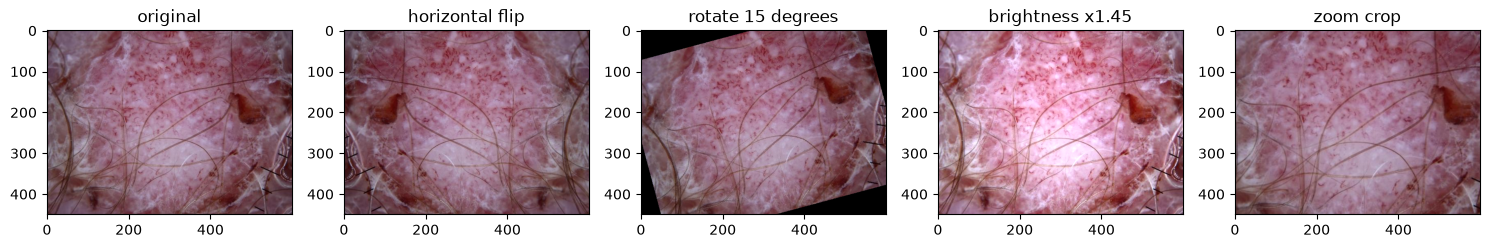

In [45]:
import os
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
from PIL import Image

IMAGE_DIR = "../data/milk10k/images"

def image_path(isic_id):
    return os.path.join(IMAGE_DIR, f"{isic_id}.jpg")

# Data Augmentation:
# Creating more images -> more from the rarest classes
sample = df.iloc[0]
img = Image.open(image_path(sample['isic_id'])).convert("RGB")
print(sample['isic_id'], sample["image_type"], sample['diagnosis_1'], img.size)

w, h = img.size
variants = {
    "original":          img,
    "horizontal flip":   TF.hflip(img),
    "rotate 15 degrees": TF.rotate(img, 15),
    "brightness x1.45":  TF.adjust_brightness(img, 1.45),
    "zoom crop":         TF.resized_crop(img, top=h // 10, left=w // 10, height=int(h * 0.8), width=int(w * 0.8), size=(h, w))
}

fig, axes = plt.subplots(1, len(variants), figsize=(15, 3))
for ax, (name, im) in zip(axes, variants.items()):
    ax.imshow(im); ax.set_title(name)
plt.tight_layout()
plt.show()